## CONSULTAS
1- ¿Como sería la estructura de un dataset?
2- En batch ¿Que sería groups?

# Main Components of Deep Learning Architectures

We move from fully connected networks to convolutional architectures and the building blocks used to train them reliably. In this practical session we will cover:
- How to implement and compare a fully-connected network (`FCNet`) and a convolutional network (`CNNNet`) in PyTorch.
- How input/output tensor shapes change through convolution, pooling, and fully-connected layers, and how that drives each model's parameter count.
- How batch normalization affects training dynamics and the distribution of internal activations.
- How the choice of optimizer (SGD vs. Adam) affects convergence speed.
- How to move models and data across devices (CPU/GPU/MPS).

In [7]:
# Let's start by importing torch (you might need to pip install if you haven't already)
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

torch.manual_seed(0)

# Get the MNIST dataset
# Set up the data preprocessing and loading:
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
)  # transform the data to torch tensor and normalize
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Now let's split the training set into a training and validation set
generator = torch.Generator().manual_seed(42)  # just a random generator
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [50000, 10000], generator=generator)

print('We loaded {} training, {} validation, and {} testing samples'.format(len(train_dataset), len(val_dataset), len(test_dataset)))

# Set up the data loaders (they are iterable objects that return the data in batches)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

We loaded 50000 training, 10000 validation, and 10000 testing samples


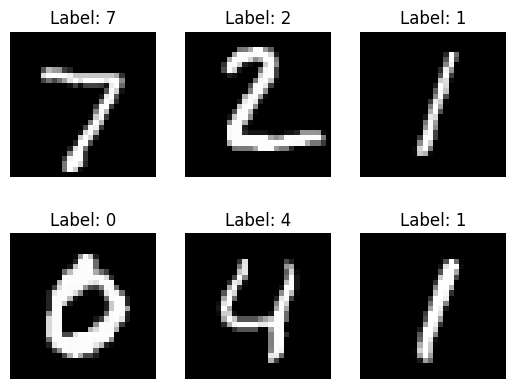

In [8]:
# Visualize some of the data 
import matplotlib.pyplot as plt
import numpy as np

examples = enumerate(test_loader)
batch_idx, (images, labels) = next(examples)
images = images.numpy()  # convert images to numpy for display
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i][0], cmap='gray'); plt.axis('off')
    plt.title('Label: {}'.format(labels[i]))

### Let's compare a fully connected network with a convolutional network

In [ ]:
# Let's define the neural network architecture to learn how to classify the images
import torch.nn as nn

# Define the model 
class FCNet(nn.Module):
    def __init__(self):
        super(FCNet, self).__init__()
        self.fc1 = nn.Linear(28*28, 128) #transforms 28x28 to 128 linear
        self.relu1 = nn.ReLU() # activation. Number stays the same
        self.fc2 = nn.Linear(128, 64) #Linear from 128 to 64
        self.relu2 = nn.ReLU() #activation. Number stays the same
        self.fc3 = nn.Linear(64, 10) #64 to 10 (number of labels)
        
    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)  # raw logits -- nn.CrossEntropyLoss applies log-softmax internally
        return x


# Define the model 
class CNNNet(nn.Module):
    def __init__(self):
        super(CNNNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  
        self.reluconv1 = nn.ReLU() 
        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2) 
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) 
        self.reluconv2 = nn.ReLU() 
        self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2)  
        self.fc1 = nn.Linear(7*7*64, 16)  
        self.relufc1 = nn.ReLU() 
        self.fc2 = nn.Linear(16, 10) 
    def forward(self, x):
        x = self.reluconv1(self.conv1(x))
        x = self.maxpool1(x)
        x = self.reluconv2(self.conv2(x))
        x = self.maxpool2(x)
        x = x.view(-1, 7*7*64)
        x = self.relufc1(self.fc1(x))
        x = self.fc2(x)  # raw logits -- nn.CrossEntropyLoss applies log-softmax internally
        return x

# ----------------------------------------------------------------------------- 
# Exercise 1: Define the input and output sizes of each tensor in the model
# -----------------------------------------------------------------------------
# super(CNNNet, self).__init__()
# self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # Nx1x28x28 -> Nx32x28x28 
# self.reluconv1 = nn.ReLU() # Nx32x28x28 -> Nx32x28x28
# self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # Nx32x28x28 -> Nx32x14x14
# self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # Nx32x14x14 -> Nx64x14x14
# self.reluconv2 = nn.ReLU() # Nx64x14x14 -> Nx64x14x14
# self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # Nx64x14x14 -> Nx64x7x7
# self.fc1 = nn.Linear(7*7*64, 16)  # Nx64x7x7 -> Nx16
# self.relufc1 = nn.ReLU() # Nx16 -> Nx16
# self.fc2 = nn.Linear(16, 10) # Nx16 -> Nx10
# -----------------------------------------------------------------------------


**Note on the loss:** as in Session6, `nn.CrossEntropyLoss` (used below) already applies `log_softmax` internally, so both models above return raw logits rather than log-probabilities — stacking a `LogSoftmax` here (as an earlier version of this notebook did) would silently apply it twice and distort the loss (see Session6's note on this exact trap).

### Exercise 2: Draw a schematic representation of both models. How many trainable parameters do they have? How many parameters would the models have if the input image was 100x100 or 1000x1000 pixels, respectively?

FCNet:
[Input: 1xHxW] -> [Flatten: (H*W)] -> [FC1: 128] -> [ReLU] -> [FC2: 64] -> [ReLU] -> [FC3: 10]


CNNNet:
[Input: 1xHxW] -> [Conv1: 32ch, 3x3] -> [ReLU] -> [MaxPool 2x2] 
               -> [Conv2: 64ch, 3x3] -> [ReLU] -> [MaxPool 2x2] 
               -> [Flatten: (H/4 * W/4 * 64)] -> [FC1: 16] -> [ReLU] -> [FC2: 10]

In [4]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"FCNet  (28x28): {count_params(FCNet()):,}")
print(f"CNNNet (28x28): {count_params(CNNNet()):,}")

FCNet  (28x28): 109,386
CNNNet (28x28): 69,178


In [11]:
# Let's visualize the model graph with tensorboard
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter("torchlogs/")
cnnmodel = CNNNet()
images, labels = next(iter(test_loader))
writer.add_graph(cnnmodel, images)
writer.close()

f:\PERSONALES\_PROJECTS\dlfcv-lab\.venv\Lib\site-packages\torch\jit\_trace.py:1006: FutureWarning: `torch.jit.trace` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
f:\PERSONALES\_PROJECTS\dlfcv-lab\.venv\Lib\site-packages\torch\jit\_trace.py:1145: FutureWarning: `torch.jit.trace_method` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## Now let's train both models and compare them

All training in this notebook runs on CPU by design — these are small models on MNIST, so both trainings together take roughly 3 minutes on this machine (10 epochs each). See Exercise 6 to compare GPU/MPS performance using the standard device idiom: `device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")`, then `model.to(device)` and `images, labels = images.to(device), labels.to(device)`.

In [12]:
# Now let's train the model
import torch.optim as optim


def compute_model_accuracy(dataloader, model):
    model.eval()  # switch to eval mode -- dropout/batchnorm behave differently at eval time
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in dataloader:  # iterate over the batches of the dataloader
            outputs = model(images)  # raw class scores (a vector of scores, one per class)
            _, predicted = torch.max(outputs.data, 1)  # predicted label = highest-scoring class
            total += labels.size(0)  # number of samples in the batch
            correct += (predicted == labels).sum().item()  # number of correctly classified samples
    model.train()  # restore training mode for the caller
    return correct / total  # return the accuracy


def train_model(
    model=None, train_loader=None, val_loader=None, log_folder=None, num_epochs=10, optimizer_name="sgd", lr=0.01
):
    writer = SummaryWriter(log_folder)  # create a tensorboard writer to log the training process
    criterion = nn.CrossEntropyLoss()  # define the loss function as the cross entropy loss
    if optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr)

    for epoch in range(num_epochs):
        model.train()  # set the model to training mode
        for batch_idx, (images, labels) in enumerate(train_loader):
            optimizer.zero_grad()  # zero the gradients
            output = model(images)  # forward pass
            loss = criterion(output, labels)  # compute the loss
            loss.backward()  # backward pass
            optimizer.step()  # update the weights

            if batch_idx % 100 == 0:  # log running train loss every 100 batches
                writer.add_scalar('training loss', loss.item(), epoch * len(train_loader) + batch_idx)

        # Log accuracy once per epoch (outside the batch loop), on the validation set only --
        # computing it more often buys little extra insight for many more forward passes.
        val_accuracy = compute_model_accuracy(val_loader, model)
        writer.add_scalar('validation accuracy', val_accuracy, epoch)

    writer.close()
    return model

In [9]:
fcmodel = FCNet()
fcmodel = train_model(model=fcmodel, train_loader=train_loader, val_loader=val_loader, log_folder="torchlogs/fcnet")

In [10]:
cnnmodel = CNNNet()
cnnmodel = train_model(model=cnnmodel, train_loader=train_loader, val_loader=val_loader, log_folder="torchlogs/cnnnet")

### Exercise 3: Add batch normalization layers to the convolutional network and compare the results. Extra: compare other normalization layers. 

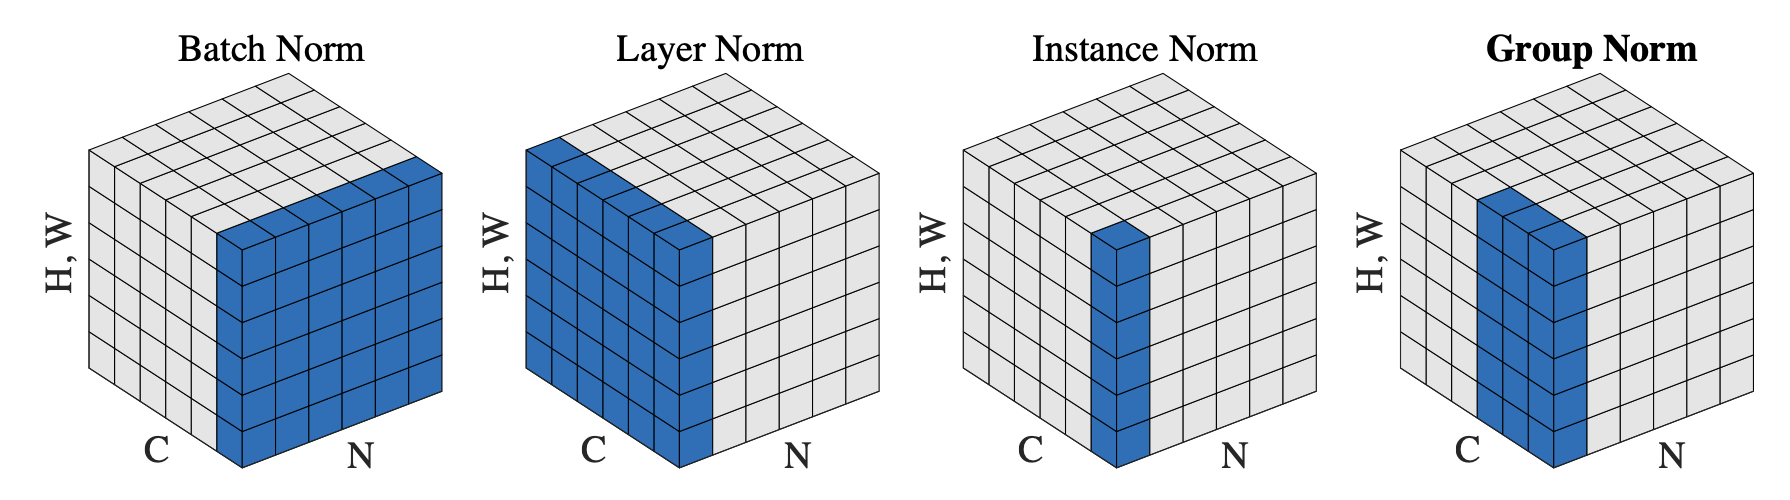


In [13]:
import torch
import torch.nn as nn

# 1. CNN with Batch Normalization (BatchNorm2d / BatchNorm1d)
class CNNNetBN(nn.Module):
    def __init__(self):
        super(CNNNetBN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.reluconv1 = nn.ReLU()
        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.reluconv2 = nn.ReLU()
        self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.fc1 = nn.Linear(7 * 7 * 64, 16)
        self.bn_fc = nn.BatchNorm1d(16)
        self.relufc1 = nn.ReLU()
        self.fc2 = nn.Linear(16, 10)

    def forward(self, x):
        x = self.maxpool1(self.reluconv1(self.bn1(self.conv1(x))))
        x = self.maxpool2(self.reluconv2(self.bn2(self.conv2(x))))
        x = x.view(-1, 7 * 7 * 64)
        x = self.relufc1(self.bn_fc(self.fc1(x)))
        x = self.fc2(x)
        return x


# Extra: Modular CNN supporting BatchNorm, LayerNorm, InstanceNorm, GroupNorm
class CNNNetNorm(nn.Module):
    def __init__(self, norm_type="batch"):
        super(CNNNetNorm, self).__init__()
        
        def get_norm2d(channels):
            if norm_type == "batch":
                return nn.BatchNorm2d(channels)
            elif norm_type == "instance":
                return nn.InstanceNorm2d(channels, affine=True)
            elif norm_type == "group":
                return nn.GroupNorm(num_groups=4, num_channels=channels)
            elif norm_type == "layer":
                return nn.GroupNorm(num_groups=1, num_channels=channels)  # LN over channels
            else:
                return nn.Identity()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.norm1 = get_norm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.norm2 = get_norm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(7 * 7 * 64, 16)
        self.relu_fc = nn.ReLU()
        self.fc2 = nn.Linear(16, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.norm1(self.conv1(x))))
        x = self.pool2(self.relu2(self.norm2(self.conv2(x))))
        x = x.view(-1, 7 * 7 * 64)
        x = self.relu_fc(self.fc1(x))
        x = self.fc2(x)
        return x


In [13]:
# Train Baseline vs BatchNorm
cnn_baseline = train_model(CNNNet(), train_loader, val_loader, "torchlogs/cnn_baseline")
cnn_bn = train_model(CNNNetBN(), train_loader, val_loader, "torchlogs/cnn_bn")

# Extra: Train LayerNorm, InstanceNorm, GroupNorm
cnn_ln = train_model(CNNNetNorm("layer"), train_loader, val_loader, "torchlogs/cnn_ln")
cnn_in = train_model(CNNNetNorm("instance"), train_loader, val_loader, "torchlogs/cnn_in")
cnn_gn = train_model(CNNNetNorm("group"), train_loader, val_loader, "torchlogs/cnn_gn")

# Compare final validation accuracies
models = {
    "No Norm (Baseline)": cnn_baseline,
    "BatchNorm": cnn_bn,
    "LayerNorm": cnn_ln,
    "InstanceNorm": cnn_in,
    "GroupNorm": cnn_gn
}

for name, model in models.items():
    acc = compute_model_accuracy(val_loader, model)
    print(f"{name:20s}: {acc * 100:.2f}%")


No Norm (Baseline)  : 98.02%
BatchNorm           : 98.15%
LayerNorm           : 98.52%
InstanceNorm        : 96.65%
GroupNorm           : 98.44%


<!-- ### Exercise 4: Plot the distribution of activation values for the first 3 neurons of the first FC layer, both for the models with BatchNorm and without.  -->

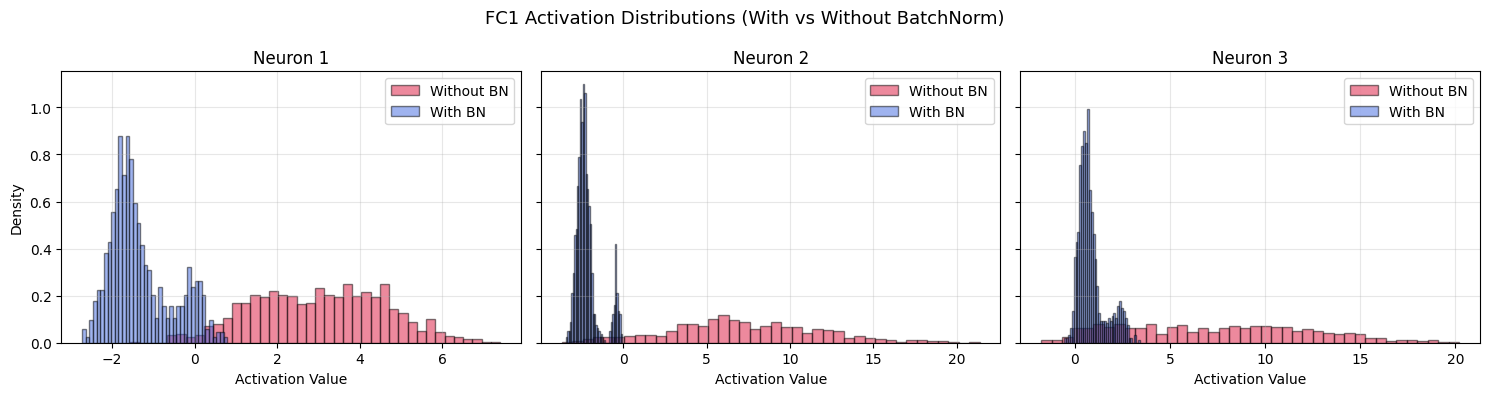

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import torch
def extract_fc1_activations(model, dataloader, num_batches=15):
    """Collects output activations of the first FC layer."""
    model.eval()
    activations = []
    
    # Register forward hook on fc1
    def hook_fn(module, input, output):
        activations.append(output.detach().cpu())
        
    handle = model.fc1.register_forward_hook(hook_fn)
    
    with torch.no_grad():
        for idx, (images, _) in enumerate(dataloader):
            if idx >= num_batches:
                break
            _ = model(images)
            
    handle.remove()
    return torch.cat(activations, dim=0).numpy()  # shape: [N_samples, 16]
# 1. Extract activations
acts_no_bn = extract_fc1_activations(cnn_baseline, val_loader)
acts_with_bn = extract_fc1_activations(cnn_bn, val_loader)
# 2. Plot distributions for the first 3 neurons
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for neuron_idx in range(3):
    ax = axes[neuron_idx]
    
    ax.hist(acts_no_bn[:, neuron_idx], bins=40, density=True, alpha=0.5, 
            label="Without BN", color="crimson", edgecolor="black")
    ax.hist(acts_with_bn[:, neuron_idx], bins=40, density=True, alpha=0.5, 
            label="With BN", color="royalblue", edgecolor="black")
    
    ax.set_title(f"Neuron {neuron_idx + 1}")
    ax.set_xlabel("Activation Value")
    if neuron_idx == 0:
        ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle("FC1 Activation Distributions (With vs Without BatchNorm)", fontsize=13)
plt.tight_layout()
plt.show()

### Exercise 5: Compare different optimization algorithms and compare their performance and training curves. In particular, explain the differences between Adam and SGD.

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

def train_with_optimizer(opt_name, lr, num_epochs=8):
    model = CNNNet()
    criterion = nn.CrossEntropyLoss()
    
    if opt_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif opt_name == "SGD+Momentum":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif opt_name == "RMSprop":
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    elif opt_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif opt_name == "AdamW":
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    train_losses, val_accuracies = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_losses.append(running_loss / len(train_loader))
        val_accuracies.append(compute_model_accuracy(val_loader, model))

    return train_losses, val_accuracies

# Run comparisons
configs = {
    "SGD (lr=0.05)": ("SGD", 0.05),
    "SGD+Mom (lr=0.01)": ("SGD+Momentum", 0.01),
    "RMSprop (lr=0.001)": ("RMSprop", 0.001),
    "Adam (lr=0.001)": ("Adam", 0.001),
    "AdamW (lr=0.001)": ("AdamW", 0.001)
}

results = {}
for label, (opt, lr) in configs.items():
    print(f"Training {label}...")
    losses, accs = train_with_optimizer(opt, lr)
    results[label] = (losses, accs)


Training SGD (lr=0.05)...


KeyboardInterrupt: 

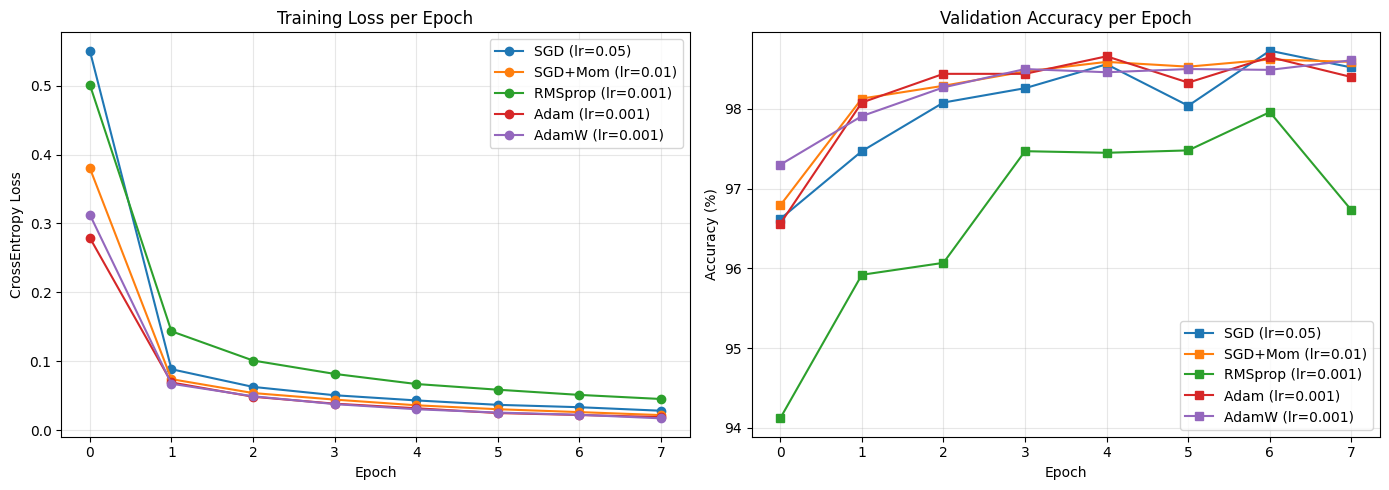

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for label, (losses, accs) in results.items():
    ax1.plot(losses, label=label, marker='o')
    ax2.plot([a * 100 for a in accs], label=label, marker='s')

ax1.set_title("Training Loss per Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("CrossEntropy Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_title("Validation Accuracy per Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Exercise 6: Depending on your hardware, compare the performance of setting PyTorch to use your GPU, for mac users (this is optional) check MLX
https://github.com/ml-explore/mlx

In [15]:
import time
import torch
import torch.nn as nn
import torch.optim as optim

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

def benchmark_device(device_name, num_epochs=3):
    device = torch.device(device_name)
    model = CNNNet().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    # Warmup
    dummy = torch.randn(64, 1, 28, 28, device=device)
    _ = model(dummy)
    if device.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.perf_counter()
    
    for epoch in range(num_epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
    if device.type == "cuda":
        torch.cuda.synchronize()
        
    total_time = time.perf_counter() - start_time
    total_samples = num_epochs * len(train_loader.dataset)
    throughput = total_samples / total_time
    
    print(f"[{device_name.upper():4s}] Time: {total_time:.2f}s | Throughput: {throughput:.1f} img/s")
    return total_time




In [16]:
# Run Comparison
cpu_time = benchmark_device("cpu", num_epochs=3)
if torch.cuda.is_available():
    gpu_time = benchmark_device("cuda", num_epochs=3)
    print(f"\n⚡ Speedup GPU vs CPU: {cpu_time / gpu_time:.2f}x")

[CPU ] Time: 107.10s | Throughput: 1400.5 img/s
[CUDA] Time: 49.26s | Throughput: 3045.0 img/s

⚡ Speedup GPU vs CPU: 2.17x


In [1]:
import torch

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"Current Device: {torch.cuda.get_device_name(0)}")
    
    # Run a quick test on the GPU
    device = torch.device("cuda")
    x = torch.rand(3, 3, device=device)
    print("\nSuccessfully allocated tensor on GPU:\n", x)
else:
    print("\nCUDA is not available. PyTorch is running on the CPU.")

PyTorch Version: 2.14.0+cu132
CUDA Available: True
Current Device: NVIDIA GeForce RTX 4070 Ti

Successfully allocated tensor on GPU:
 tensor([[0.4456, 0.4333, 0.5079],
        [0.2819, 0.8377, 0.1338],
        [0.3287, 0.3420, 0.4117]], device='cuda:0')
